# Fraud Detection - Data Mining Pipeline

## Mục Tiêu
- Đọc và kiểm tra dữ liệu gốc, phát hiện vấn đề tiềm ẩn
- Thực hiện Phân Tích Dữ Liệu Khám Phá (EDA) theo logic học thuật, từ tổng quan đến chi tiết
- Xây dựng feature engineering cho giao dịch, thời gian và vị trí địa lý (sử dụng công thức Haversine)
- Lựa chọn features quan trọng (Feature Selection) dựa trên correlation, mutual information, tree importance
- Xử lý imbalance dữ liệu (SMOTE hoặc Undersampling)
- Xây dựng baseline và các mô hình dựa trên cây (tree-based models)
- Đánh giá bằng precision, recall, F1, ROC-AUC, PR-AUC
- Chọn threshold hợp lý cho bài toán fraud detection (threshold tuning)

## Cấu Trúc Pipeline Data Mining

```
RAW DATA
   │
   ▼
[1] SETUP & IMPORT
   │
   ▼
[2] DATA CLEANING (Làm sạch dữ liệu)
   ├─ Xử lý missing values
   ├─ Xóa duplicate rows
   ├─ Loại bỏ outliers
   └─ Xóa cột hằng
   │
   ▼
[3] EXPLORATORY DATA ANALYSIS (EDA)
   ├─ Phân tích phân bố target
   ├─ Phân tích features gốc
   └─ Phát hiện patterns
   │
   ▼
[4] DATA TRANSFORMATION
   ├─ Feature Engineering (tạo features mới)
   ├─ Encoding (categorical → số)
   ├─ Scaling (StandardScaler)
   └─ Feature analysis (correlation, MI)
   │
   ▼
[5] DATA REDUCTION (Feature Selection)
   ├─ Correlation-based ranking
   ├─ Mutual Information ranking
   ├─ Tree-based importance ranking
   └─ Consolidate & select top features
   │
   ▼
[6] PREPROCESSING & SPLIT
   ├─ Train/Validation/Test split
   ├─ Pipeline setup (Impute, Scale, Encode)
   └─ Prepare final dataset
   │
   ▼
[7] HANDLE IMBALANCE (nếu cần)
   ├─ SMOTE (tạo synthetic samples)
   └─ Undersampling (giảm majority class)
   │
   ▼
===============================
      READY FOR MODEL TRAINING
===============================
   │
   ▼
[8] MODEL TRAINING & TUNING
   ├─ Logistic Regression (baseline)
   ├─ Random Forest
   ├─ Extra Trees Classifier
   └─ Threshold tuning
   │
   ▼
[9] EVALUATION & FINAL RESULTS
   ├─ ROC-AUC, PR-AUC, F1
   ├─ Classification Report
   └─ Final submission
```

## Chi Tiết Sections

### 1. SETUP & IMPORT
- Setup và import thư viện

### 2. TIỀN XỬ LÝ DỮ LIỆU
- **2.1 Trích xuất dữ liệu**: Nạp dữ liệu từ file CSV
- **2.2 Kiểm tra nhanh dataset**: Tổng quan hình dạng, tỷ lệ fraud, missing values
- **2.3 EDA cơ bản**: Phân tích dữ liệu gốc (kiểu dữ liệu, giá trị thiếu, fraud rate by category/state/gender)
- **2.4 Làm sạch dữ liệu**: Xử lý missing, duplicates, loại bỏ cột hằng, outliers

### 3. FEATURE ENGINEERING & ANALYSIS
- **2.5 Feature Engineering**: Tạo features (hour, age, distance_km, amt_log, velocity, merchant reputation, etc.)
- **2.5.1-2.5.6**: EDA mở rộng - phân tích các features mới

### 4. FEATURE SELECTION & REDUCTION
- **2.6 Lựa chọn Đặc Trưng**: Ranking features bằng 3 tiêu chí (Correlation, MI, Tree Importance)

### 5. PREPROCESSING & DATA SPLIT
- **2.7 Tiền xử lý chính thức**: Pipeline (impute, scale, encode) + Train/Val/Test split

### 6. HANDLE IMBALANCE
- **2.8 Xử lý Imbalance**: SMOTE hoặc Undersampling (optional)

### 7. MODEL TRAINING & EVALUATION
- **3.1 Huấn luyện mô hình**: So sánh Logistic, Random Forest, Extra Trees
- **3.2 Tuning threshold**: Tối ưu ngưỡng quyết định
- **3.3 Đánh giá trên test set**: Kết quả cuối cùng

### 8. RESULTS & REPORTING
- **4. Báo cáo**: Lưu artifacts, classification report, kết quả

## 1. Setup và Import Thư Viện

Phần này thực hiện các tác vụ chuẩn bị:
- Import các thư viện cần thiết (pandas, numpy, scikit-learn, matplotlib, seaborn)
- Thiết lập random seed để đảm bảo kết quả có thể tái hiện
- Tạo thư mục lưu kết quả (artifacts, data)

Nếu môi trường còn thiếu package, hãy mở comment dòng `%pip install`. Nếu bạn muốn notebook tự tải dataset, có thể cài thêm `kagglehub` hoặc `kaggle`.

In [5]:
# %pip install -U pandas numpy matplotlib seaborn scikit-learn imbalanced-learn kagglehub kaggle


In [6]:
from pathlib import Path
import os
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
SAMPLE_FRAC = None  # Vi du: 0.2 neu muon chay nhanh hon
DOWNLOAD_METHOD = "kagglehub"  # None | 'kagglehub' | 'kaggle_api'
KAGGLE_DATASET = "kartik2112/fraud-detection"
TARGET = "is_fraud"
ARTIFACT_DIR = Path("../artifacts") if Path.cwd().name == "notebooks" else Path("artifacts")
DATA_DIR = Path("../data") if Path.cwd().name == "notebooks" else Path("data")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts will be saved to:", ARTIFACT_DIR.resolve())
print("Data directory:", DATA_DIR.resolve())
print("Download method:", DOWNLOAD_METHOD)

Artifacts will be saved to: D:\Code\BTL\Data mining\Fraud detection\artifacts
Data directory: D:\Code\BTL\Data mining\Fraud detection\data
Download method: kagglehub


In [7]:
def find_data_file(filename: str) -> Path:
    search_roots = [Path.cwd(), Path.cwd().parent, DATA_DIR]
    checked = []
    for root in search_roots:
        direct = root / filename
        data_dir = root / "data" / filename
        for candidate in [direct, data_dir]:
            checked.append(candidate)
            if candidate.exists():
                return candidate
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Khong tim thay {filename}. Da tim trong: {checked}.")

def ensure_dataset_downloaded(method: str | None):
    if method is None:
        raise FileNotFoundError(
            "Khong tim thay dataset local va DOWNLOAD_METHOD=None. "
            "Hay dat fraudTrain.csv/fraudTest.csv vao thu muc data/ hoac doi DOWNLOAD_METHOD sang 'kagglehub' hoac 'kaggle_api'."
        )

    train_candidate = DATA_DIR / "fraudTrain.csv"
    test_candidate = DATA_DIR / "fraudTest.csv"
    if train_candidate.exists() and test_candidate.exists():
        print("Dataset da ton tai trong data/. Bo qua buoc tai.")
        return

    if method == "kagglehub":
        try:
            import kagglehub
        except ImportError as exc:
            raise ImportError(
                "Chua cai kagglehub. Hay chay `%pip install kagglehub` roi chay lai cell nay."
            ) from exc
        downloaded_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        for name in ["fraudTrain.csv", "fraudTest.csv"]:
            src = downloaded_dir / name
            dst = DATA_DIR / name
            if not src.exists():
                raise FileNotFoundError(f"Khong tim thay {name} trong thu muc kagglehub: {downloaded_dir}")
            if not dst.exists():
                shutil.copy2(src, dst)
        print(f"Downloaded via kagglehub to: {DATA_DIR.resolve()}")
        return

    if method == "kaggle_api":
        if not shutil.which("kaggle"):
            raise RuntimeError("Khong tim thay lenh `kaggle`. Hay cai package kaggle truoc.")
        cmd = [
            "kaggle", "datasets", "download",
            "-d", KAGGLE_DATASET,
            "-p", str(DATA_DIR),
            "--unzip",
        ]
        subprocess.run(cmd, check=True)
        print(f"Downloaded via Kaggle API to: {DATA_DIR.resolve()}")
        return

    raise ValueError("DOWNLOAD_METHOD phai la None, 'kagglehub' hoac 'kaggle_api'.")

try:
    train_path = find_data_file("fraudTrain.csv")
    test_path = find_data_file("fraudTest.csv")
except FileNotFoundError as first_error:
    print(f"[Info] {first_error}")
    ensure_dataset_downloaded(DOWNLOAD_METHOD)
    train_path = find_data_file("fraudTrain.csv")
    test_path = find_data_file("fraudTest.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

if SAMPLE_FRAC is not None:
    train_df = train_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    test_df = test_df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)

print(f"Train path: {train_path}")
print(f"Test path:  {test_path}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train path: d:\Code\BTL\Data mining\Fraud detection\data\fraudTrain.csv
Test path:  d:\Code\BTL\Data mining\Fraud detection\data\fraudTest.csv
Train shape: (1296675, 23)
Test shape:  (555719, 23)


In [8]:
# ===== 1.2 SPLIT TRAIN/VALIDATION/TEST - Chronological Split để giảm leakage =====
print("=" * 70)
print("1.2 TRAIN/VALIDATION/TEST SPLIT - Chronological Split")
print("=" * 70)

# Dataset fraudTrain/fraudTest trong bộ dữ liệu này đều có label.
# Quy ước ở notebook:
# - train_df: dữ liệu huấn luyện gốc, sẽ được tách train/validation theo thời gian
# - test_df: holdout test riêng, giữ nguyên để đánh giá cuối cùng
train_df = train_df.copy()
test_df = test_df.copy()

train_df["trans_date_trans_time"] = pd.to_datetime(train_df["trans_date_trans_time"], errors="coerce")
test_df["trans_date_trans_time"] = pd.to_datetime(test_df["trans_date_trans_time"], errors="coerce")

train_df = train_df.sort_values("trans_date_trans_time").reset_index(drop=True)
test_df = test_df.sort_values("trans_date_trans_time").reset_index(drop=True)

split_idx = int(len(train_df) * 0.8)
train_split = train_df.iloc[:split_idx].copy()
validation_split = train_df.iloc[split_idx:].copy()

train_cards = set(train_split["cc_num"].unique())
validation_cards = set(validation_split["cc_num"].unique())
overlap_cards = len(train_cards & validation_cards)

print("\n✓ Chronological split từ fraudTrain.csv:")
print(f"  - train_split: {train_split.shape[0]:,} rows")
print(f"  - validation_split: {validation_split.shape[0]:,} rows")
print(f"  - test_df holdout: {test_df.shape[0]:,} rows")

print("\n✓ Time range:")
print(f"  - train_split: {train_split['trans_date_trans_time'].min()} -> {train_split['trans_date_trans_time'].max()}")
print(f"  - validation_split: {validation_split['trans_date_trans_time'].min()} -> {validation_split['trans_date_trans_time'].max()}")
print(f"  - test_df holdout: {test_df['trans_date_trans_time'].min()} -> {test_df['trans_date_trans_time'].max()}")

print("\n✓ Fraud rate sau split:")
print(f"  - train_split: {train_split[TARGET].mean():.4f}")
print(f"  - validation_split: {validation_split[TARGET].mean():.4f}")
print(f"  - test_df holdout: {test_df[TARGET].mean():.4f}")

print("\n✓ Overlap cardholder giữa train và validation (theo cc_num):")
print(f"  - overlap_cards: {overlap_cards:,} / {len(validation_cards):,} validation cards")
print("  - Lưu ý: split theo thời gian giảm leakage do nhìn thấy tương lai, nhưng chưa loại bỏ overlap khách hàng.")

print("\n✓ Từ đây về sau:")
print("  1. Feature engineering fit/statistics lấy từ train_split")
print("  2. Feature selection xếp hạng trên train_split")
print("  3. Modeling train trên train_split, tune trên validation_split")
print("  4. Đánh giá cuối cùng trên test_df holdout")


1.2 TRAIN/VALIDATION/TEST SPLIT - Chronological Split

✓ Chronological split từ fraudTrain.csv:
  - train_split: 1,037,340 rows
  - validation_split: 259,335 rows
  - test_df holdout: 555,719 rows

✓ Time range:
  - train_split: 2019-01-01 00:00:18 -> 2020-03-06 07:15:17
  - validation_split: 2020-03-06 07:16:43 -> 2020-06-21 12:13:37
  - test_df holdout: 2020-06-21 12:14:25 -> 2020-12-31 23:59:34

✓ Fraud rate sau split:
  - train_split: 0.0058
  - validation_split: 0.0059
  - test_df holdout: 0.0039

✓ Overlap cardholder giữa train và validation (theo cc_num):
  - overlap_cards: 908 / 927 validation cards
  - Lưu ý: split theo thời gian giảm leakage do nhìn thấy tương lai, nhưng chưa loại bỏ overlap khách hàng.

✓ Từ đây về sau:
  1. Feature engineering fit/statistics lấy từ train_split
  2. Feature selection xếp hạng trên train_split
  3. Modeling train trên train_split, tune trên validation_split
  4. Đánh giá cuối cùng trên test_df holdout


## 2.2 Kiểm Tra Nhanh Dataset

Phần này tạo bảng tổng quan : số dòng, số cột, tỷ lệ gian lận, và tổng số giá trị thiếu. Đây là bước quan trọng để hiểu kích thước và đặc điểm tổng thể của dữ liệu.

In [9]:
summary_df = pd.DataFrame({
    "tập_dữ_liệu": ["train", "test"],
    "số_dòng": [len(train_df), len(test_df)],
    "số_cột": [train_df.shape[1], test_df.shape[1]],
    "tỷ_lệ_fraud": [train_df[TARGET].mean(), test_df[TARGET].mean()],
    "tổng_giá_trị_thiếu": [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
})
summary_df

,tập_dữ_liệu,số_dòng,số_cột,tỷ_lệ_fraud,tổng_giá_trị_thiếu
0,train,1296675,23,0.005789,0
1,test,555719,23,0.003860,0


In [10]:
n_rows = 5

train_preview = pd.read_csv(train_path, nrows=n_rows)
test_preview = pd.read_csv(test_path, nrows=n_rows)

print(f"{n_rows} dòng đầu của train:")
display(train_preview)

print(f"{n_rows} dòng đầu của test:")
display(test_preview)

5 dòng đầu của train:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


5 dòng đầu của test:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


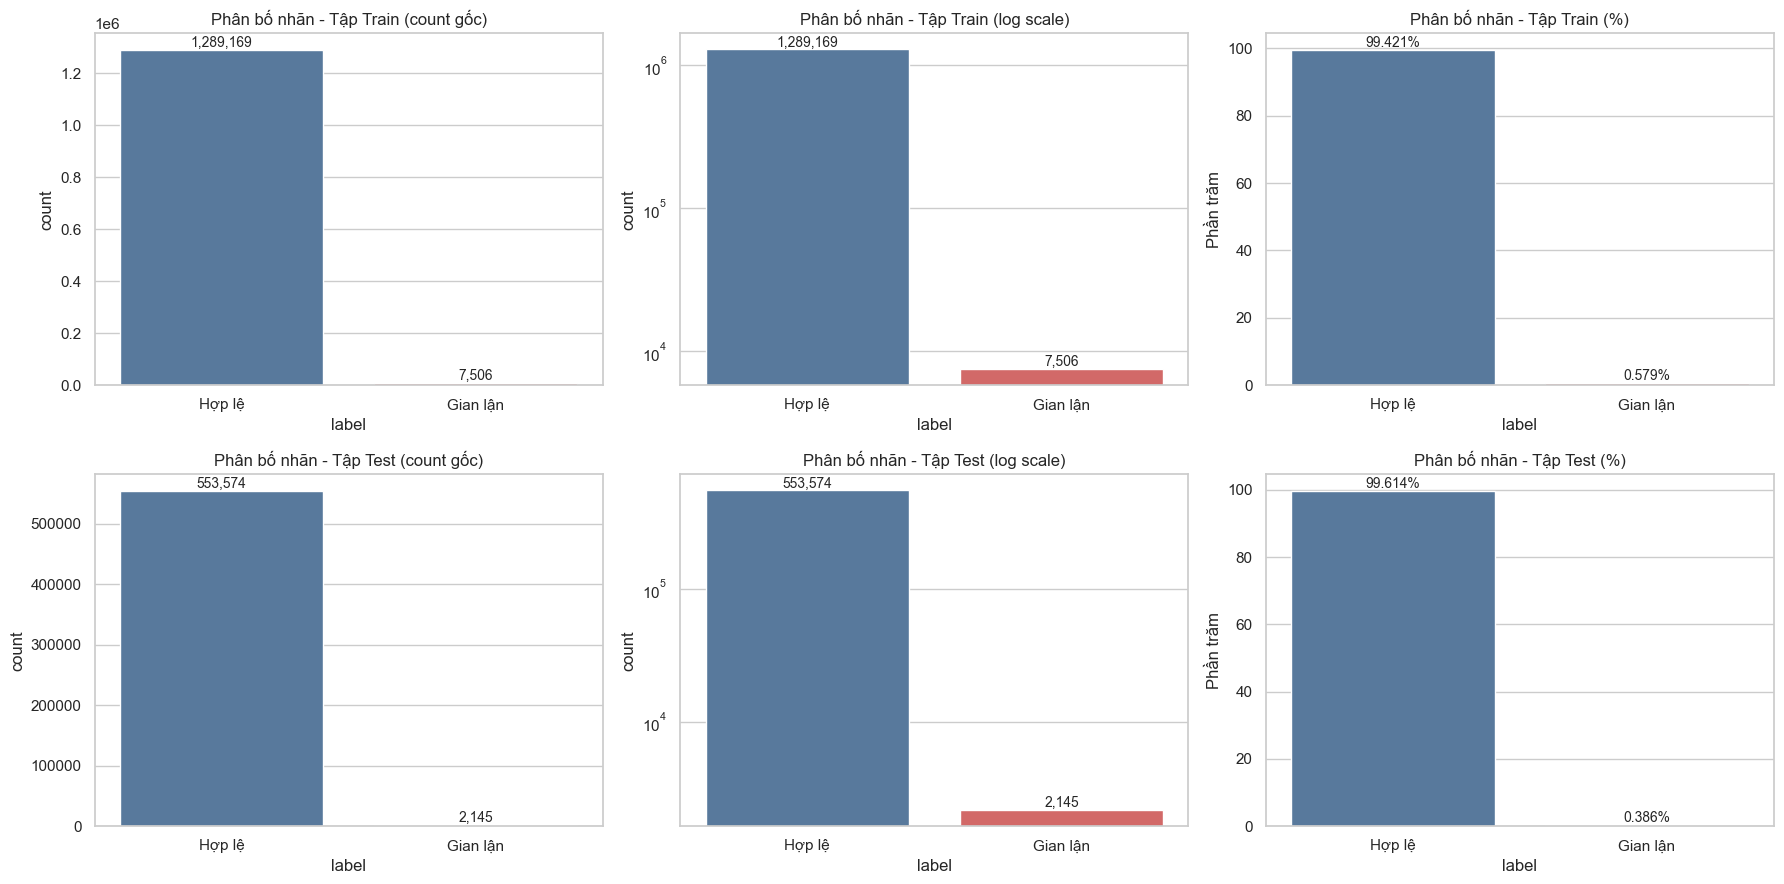

Bảng phân bố lớp - train:


,label,count,pct
0,Hợp lệ,1289169,99.421135
1,Gian lận,7506,0.578865


Bảng phân bố lớp - test:


,label,count,pct
0,Hợp lệ,553574,99.614014
1,Gian lận,2145,0.385986


In [11]:

train_counts = train_df[TARGET].value_counts().sort_index()
test_counts = test_df[TARGET].value_counts().sort_index()

train_plot = pd.DataFrame({
    'label': ['Hợp lệ', 'Gian lận'],
    'count': [train_counts.get(0, 0), train_counts.get(1, 0)],
})
train_plot['pct'] = train_plot['count'] / train_plot['count'].sum() * 100

test_plot = pd.DataFrame({
    'label': ['Hợp lệ', 'Gian lận'],
    'count': [test_counts.get(0, 0), test_counts.get(1, 0)],
})
test_plot['pct'] = test_plot['count'] / test_plot['count'].sum() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Train
sns.barplot(data=train_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[0, 0])
axes[0, 0].set_title('Phân bố nhãn - Tập Train (count gốc)')
for idx, row in train_plot.iterrows():
    axes[0, 0].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=train_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Phân bố nhãn - Tập Train (log scale)')
for idx, row in train_plot.iterrows():
    axes[0, 1].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=train_plot, x='label', y='pct', palette=['#4C78A8', '#E45756'], ax=axes[0, 2])
axes[0, 2].set_title('Phân bố nhãn - Tập Train (%)')
axes[0, 2].set_ylabel('Phần trăm')
for idx, row in train_plot.iterrows():
    axes[0, 2].text(idx, row['pct'], f"{row['pct']:.3f}%", ha='center', va='bottom', fontsize=10)

# Test
sns.barplot(data=test_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[1, 0])
axes[1, 0].set_title('Phân bố nhãn - Tập Test (count gốc)')
for idx, row in test_plot.iterrows():
    axes[1, 0].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=test_plot, x='label', y='count', palette=['#4C78A8', '#E45756'], ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Phân bố nhãn - Tập Test (log scale)')
for idx, row in test_plot.iterrows():
    axes[1, 1].text(idx, row['count'], f"{int(row['count']):,}", ha='center', va='bottom', fontsize=10)

sns.barplot(data=test_plot, x='label', y='pct', palette=['#4C78A8', '#E45756'], ax=axes[1, 2])
axes[1, 2].set_title('Phân bố nhãn - Tập Test (%)')
axes[1, 2].set_ylabel('Phần trăm')
for idx, row in test_plot.iterrows():
    axes[1, 2].text(idx, row['pct'], f"{row['pct']:.3f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('Bảng phân bố lớp - train:')
display(train_plot)
print('Bảng phân bố lớp - test:')
display(test_plot)


## 2.3 EDA Cơ Bản

Giữ lại một số thống kê và biểu đồ chính để mô tả dữ liệu, tránh lặp lại các phân tích phụ.


In [12]:
dtype_summary = train_df.dtypes.astype(str).value_counts().rename_axis('kiểu_dữ_liệu').reset_index(name='số_cột')
missing_summary = (
    train_df.isna().sum()
    .sort_values(ascending=False)
    .rename('số_giá_trị_thiếu')
    .to_frame()
    .query('số_giá_trị_thiếu > 0')
)
amt_stats = train_df.groupby(TARGET)['amt'].describe().round(2)

# Danh mục: thêm count, fraud_count, lọc >= 100
fraud_by_category = (
    train_df.groupby('category')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .sort_values('tỷ_lệ_fraud', ascending=False)
    .reset_index()
    .query('tổng_giao_dịch >= 100')
)

# Bang/miền: thêm count, fraud_count, lọc >= 100
fraud_by_state = (
    train_df.groupby('state')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .sort_values('tỷ_lệ_fraud', ascending=False)
    .reset_index()
    .query('tổng_giao_dịch >= 100')
)

# Giới tính
fraud_by_gender = (
    train_df.groupby('gender')
    .agg({TARGET: ['sum', 'count', 'mean']})
    .droplevel(0, axis=1)
    .rename(columns={'sum': 'số_fraud', 'count': 'tổng_giao_dịch', 'mean': 'tỷ_lệ_fraud'})
    .reset_index()
)

print('Kiểu dữ liệu:')
display(dtype_summary)

print('Các cột có giá trị thiếu:')
display(missing_summary if not missing_summary.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Thống kê số tiền theo nhãn:')
display(amt_stats)

print('Danh mục theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):')
display(fraud_by_category)

print('Bang/miền theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):')
display(fraud_by_state)

print('Tỷ lệ gian lận theo giới tính:')
display(fraud_by_gender)

Kiểu dữ liệu:


,kiểu_dữ_liệu,số_cột
0,str,11
1,int64,6
2,float64,5
3,datetime64[us],1


Các cột có giá trị thiếu:


,thông_báo
0,Không có giá trị thiếu


Thống kê số tiền theo nhãn:


...

,category,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
0,shopping_net,1713,97543,0.017561
1,misc_net,915,63287,0.014458
2,grocery_pos,1743,123638,0.014098
3,shopping_pos,843,116672,0.007225
4,gas_transport,618,131659,0.004694
5,misc_pos,250,79655,0.003139
6,grocery_net,134,45452,0.002948
7,travel,116,40507,0.002864
8,entertainment,233,94014,0.002478
9,personal_care,220,90758,0.002424


Bang/miền theo tỷ lệ gian lận (chỉ nhóm có >= 100 giao dịch):


,state,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
1,RI,15,550,0.027273
2,AK,36,2120,0.016981
3,NV,47,5607,0.008382
4,CO,113,13880,0.008141
5,OR,149,18597,0.008012
6,TN,140,17554,0.007975
7,NE,180,24168,0.007448
8,ME,119,16505,0.007210
9,NH,59,8278,0.007127
10,OH,321,46480,0.006906


Tỷ lệ gian lận theo giới tính:


,gender,số_fraud,tổng_giao_dịch,tỷ_lệ_fraud
0,F,3735,709863,0.005262
1,M,3771,586812,0.006426


## 2.4 Làm Sạch Dữ Liệu

Kiểm tra nhanh target, duplicate và chất lượng dữ liệu trước khi tạo feature.


In [13]:
# 2.4.1 Kiểm tra Target, Duplicate và Tình Trạng Dữ Liệu Gốc
print("="*80)
print("2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC")
print("="*80)

# Target value counts
print("\n1. Kiểm tra TARGET")
print(f"Target column: {TARGET}")
print(f"Giá trị duy nhất: {train_df[TARGET].unique()}")
print(f"Value counts:\n{train_df[TARGET].value_counts(dropna=False)}")

# Duplicates
print("\n2. Kiểm tra DUPLICATE ROWS")
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()
print(f"Train duplicates: {train_duplicates} ({train_duplicates/len(train_df)*100:.2f}%)")
print(f"Test duplicates: {test_duplicates} ({test_duplicates/len(test_df)*100:.2f}%)")

# Summary table
data_quality = pd.DataFrame({
    'tập_dữ_liệu': ['train', 'test'],
    'số_dòng': [len(train_df), len(test_df)],
    'số_cột': [train_df.shape[1], test_df.shape[1]],
    'tỷ_lệ_fraud': [f"{train_df[TARGET].mean():.4%}", f"{test_df[TARGET].mean():.4%}"],
    'số_duplicate': [train_duplicates, test_duplicates],
    'tổng_missing': [train_df.isna().sum().sum(), test_df.isna().sum().sum()],
})
print("\n3. SUMMARY DỮ LIỆU GỐC")
display(data_quality)

# 2.4.2 Kiểm tra MISSING VALUES
print("\n" + "="*80)
print("4. MISSING VALUES (Giá Trị Thiếu)")
print("="*80)

def missing_table(df, name=""):
    """Tạo bảng thống kê missing values"""
    total_rows = len(df)
    missing = pd.DataFrame({
        'cột': df.columns,
        'số_missing': df.isna().sum().values,
        'tỷ_lệ_%': (df.isna().sum().values / total_rows * 100).round(2),
    })
    missing = missing[missing['số_missing'] > 0].sort_values('số_missing', ascending=False).reset_index(drop=True)
    return missing

train_missing = missing_table(train_df, "train")
test_missing = missing_table(test_df, "test")

print("\nTrain set:")
display(train_missing if not train_missing.empty else pd.DataFrame({'Thông báo': ['Không có missing values']}))

print("Test set:")
display(test_missing if not test_missing.empty else pd.DataFrame({'Thông báo': ['Không có missing values']}))

# 2.4.3 Kiểm tra CONSTANT COLUMNS (Cột Hằng)
print("\n" + "="*80)
print("5. CONSTANT COLUMNS (Cột Hằng / Chỉ 1 Giá Trị)")
print("="*80)

constant_cols = [col for col in train_df.columns if train_df[col].nunique(dropna=False) <= 1]
print(f"Constant columns: {constant_cols if constant_cols else 'Không có'}")

# 2.4.4 Kiểm tra CARDINALITY (Số Giá Trị Duy Nhất)
print("\n" + "="*80)
print("6. CARDINALITY (Số Giá Trị Duy Nhất)")
print("="*80)

cardinality = pd.DataFrame({
    'cột': train_df.columns,
    'kiểu': train_df.dtypes.astype(str).values,
    'số_giá_trị_duy_nhất': train_df.nunique(dropna=False).values,
    'tỷ_lệ_duy_nhất_%': (train_df.nunique(dropna=False) / len(train_df) * 100).round(2).values,
}).sort_values('số_giá_trị_duy_nhất', ascending=False)

print("\nTất cả cột:")
display(cardinality)

# Phát hiện HIGH CARDINALITY
high_card_threshold = 0.3  # >30% giá trị duy nhất
high_cardinality_cols = cardinality[cardinality['tỷ_lệ_duy_nhất_%'] > high_card_threshold * 100]['cột'].tolist()
print(f"\nCột HIGH CARDINALITY (>30%): {high_cardinality_cols if high_cardinality_cols else 'Không có'}")

# 2.4.5 Quy Định Danh Sách Cột Loại Bỏ
print("\n" + "="*80)
print("7. COLUMN DROPPING PLAN (Danh Sách Cột Loại Bỏ)")
print("="*80)

identifier_like_cols = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip',
    'trans_num', 'unix_time', 'trans_date_trans_time', 'dob',
    'city', 'merchant'
]

drop_plan = pd.DataFrame({
    'cột': identifier_like_cols,
    'lý_do': [
        'chỉ số dòng, không có ý nghĩa dự đoán',
        'định danh thẻ, nguy cơ overfitting cao',
        'tên riêng, cardinality cao',
        'tên riêng, cardinality cao',
        'địa chỉ cụ thể, cardinality cao',
        'mã zip, tính định danh cao',
        'mã giao dịch, định danh duy nhất',
        'thời gian dạng số, được thay bằng feature đã tạo',
        'đã tách thành hour/day/month',
        'đã dùng để tạo age',
        'địa danh cụ thể, giảm tổng quát hóa',
        'tên merchant cụ thể, cardinality cao'
    ]
})

display(drop_plan)

# Kiểm tra cột nào thực sự tồn tại trong dữ liệu
existing_drop_cols = [col for col in identifier_like_cols if col in train_df.columns]
print(f"\nCột sẽ loại bỏ (tồn tại trong dữ liệu): {existing_drop_cols}")
print(f"Số cột loại bỏ: {len(existing_drop_cols)}")
print(f"Số cột giữ lại: {train_df.shape[1] - len(existing_drop_cols)}")

2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC

1. Kiểm tra TARGET
Target column: is_fraud
Giá trị duy nhất: [0 1]
Value counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

2. Kiểm tra DUPLICATE ROWS
Train duplicates: 0 (0.00%)
Test duplicates: 0 (0.00%)

3. SUMMARY DỮ LIỆU GỐC


2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC

1. Kiểm tra TARGET
Target column: is_fraud
Giá trị duy nhất: [0 1]
Value counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

2. Kiểm tra DUPLICATE ROWS
Train duplicates: 0 (0.00%)
Test duplicates: 0 (0.00%)

3. SUMMARY DỮ LIỆU GỐC


,tập_dữ_liệu,số_dòng,số_cột,tỷ_lệ_fraud,số_duplicate,tổng_missing
0,train,1296675,23,0.5789%,0,0
1,test,555719,23,0.3860%,0,0


2.4 LÀM SẠCH DỮ LIỆU - KIỂM TRA CHẤT LƯỢNG DỮ LIỆU GỐC

1. Kiểm tra TARGET
Target column: is_fraud
Giá trị duy nhất: [0 1]
Value counts:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

2. Kiểm tra DUPLICATE ROWS
Train duplicates: 0 (0.00%)
Test duplicates: 0 (0.00%)

3. SUMMARY DỮ LIỆU GỐC


,tập_dữ_liệu,số_dòng,số_cột,tỷ_lệ_fraud,số_duplicate,tổng_missing
0,train,1296675,23,0.5789%,0,0
1,test,555719,23,0.3860%,0,0


...


5. CONSTANT COLUMNS (Cột Hằng / Chỉ 1 Giá Trị)
Constant columns: Không có

6. CARDINALITY (Số Giá Trị Duy Nhất)

Tất cả cột:


,cột,kiểu,số_giá_trị_duy_nhất,tỷ_lệ_duy_nhất_%
0,Unnamed: 0,int64,1296675,100.00
18,trans_num,str,1296675,100.00
21,merch_long,float64,1275745,98.39
19,unix_time,int64,1274823,98.31
1,trans_date_trans_time,datetime64[us],1274791,98.31
20,merch_lat,float64,1247805,96.23
5,amt,float64,52928,4.08
9,street,str,983,0.08
2,cc_num,int64,983,0.08
12,zip,int64,970,0.07



Cột HIGH CARDINALITY (>30%): ['Unnamed: 0', 'trans_num', 'merch_long', 'unix_time', 'trans_date_trans_time', 'merch_lat']

7. COLUMN DROPPING PLAN (Danh Sách Cột Loại Bỏ)


,cột,lý_do
0,Unnamed: 0,"chỉ số dòng, không có ý nghĩa dự đoán"
1,cc_num,"định danh thẻ, nguy cơ overfitting cao"
2,first,"tên riêng, cardinality cao"
3,last,"tên riêng, cardinality cao"
4,street,"địa chỉ cụ thể, cardinality cao"
5,zip,"mã zip, tính định danh cao"
6,trans_num,"mã giao dịch, định danh duy nhất"
7,unix_time,"thời gian dạng số, được thay bằng feature đã tạo"
8,trans_date_trans_time,đã tách thành hour/day/month
9,dob,đã dùng để tạo age



Cột sẽ loại bỏ (tồn tại trong dữ liệu): ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip', 'trans_num', 'unix_time', 'trans_date_trans_time', 'dob', 'city', 'merchant']
Số cột loại bỏ: 12
Số cột giữ lại: 11


## 2.5 Kỹ Thuật Đặc Trưng (Feature Engineering)

Tạo các feature thời gian, khoảng cách và hành vi giao dịch; phần EDA bên dưới chỉ giữ các biểu đồ có ích trực tiếp cho fraud detection.


In [14]:

def haversine_np(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return 6371.0 * c

def add_eda_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
    df["month"] = df["trans_date_trans_time"].dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    age_days = (df["trans_date_trans_time"] - df["dob"]).dt.days
    df["age"] = (age_days / 365.25).clip(lower=0)
    df["distance_km"] = haversine_np(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
    df["amt_log"] = np.log1p(df["amt"])
    return df

eda_train = add_eda_features(train_df)
eda_test = add_eda_features(test_df)

print("Hình dạng TRAIN sau EDA feature:", eda_train.shape)
print("Hình dạng TEST sau EDA feature: ", eda_test.shape)
eda_train[["trans_date_trans_time", "hour", "dayofweek", "month", "age", "distance_km", "amt_log"]].head(3)

Hình dạng TRAIN sau EDA feature: (1296675, 30)
Hình dạng TEST sau EDA feature:  (555719, 30)


,trans_date_trans_time,hour,dayofweek,month,age,distance_km,amt_log
0,2019-01-01 00:00:18,0,1,1,30.814511,78.597568,1.786747
1,2019-01-01 00:00:44,0,1,1,40.531143,30.212176,4.684259
2,2019-01-01 00:00:51,0,1,1,56.950034,108.206083,5.398660


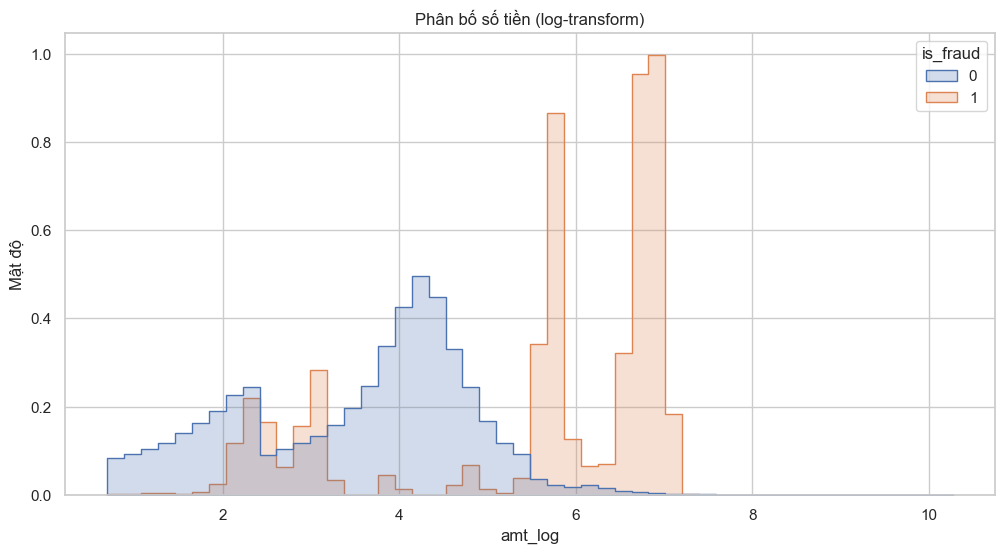

In [15]:

sns.histplot(
    data=eda_train,
    x="amt_log",
    hue=TARGET,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Phân bố số tiền (log-transform)")
plt.xlabel("amt_log")
plt.ylabel("Mật độ")
plt.show()


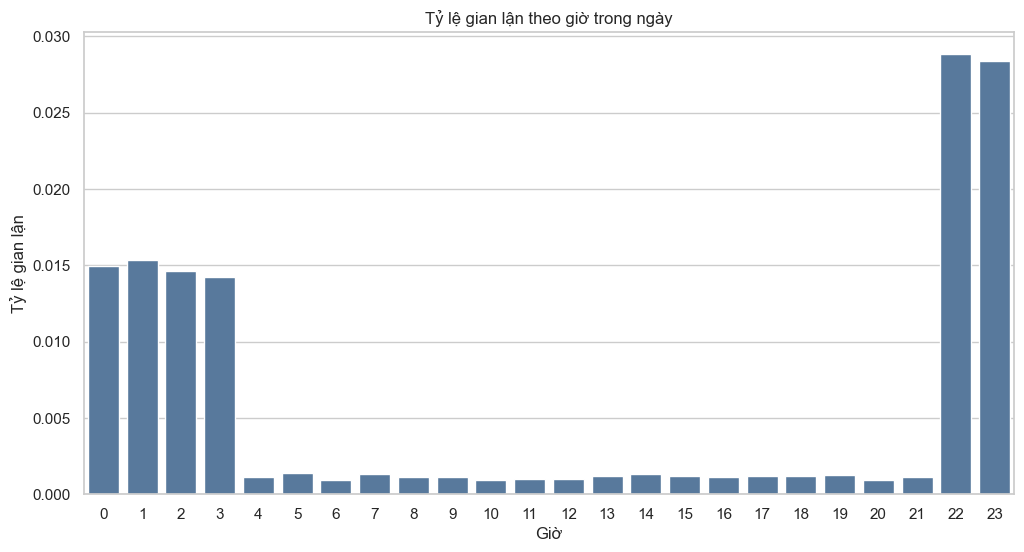

In [16]:

hourly = eda_train.groupby("hour")[TARGET].mean().reset_index()
sns.barplot(data=hourly, x="hour", y=TARGET, color="#4C78A8")
plt.title("Tỷ lệ gian lận theo giờ trong ngày")
plt.ylabel("Tỷ lệ gian lận")
plt.xlabel("Giờ")
plt.show()


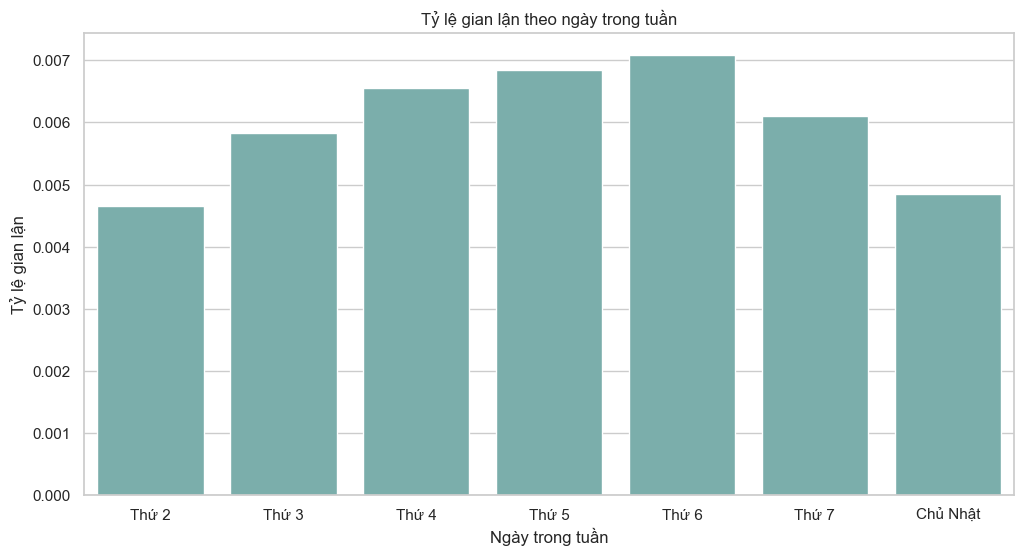

In [17]:

day_labels = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ Nhật"]
dayofweek = eda_train.groupby("dayofweek")[TARGET].mean().reset_index()
sns.barplot(data=dayofweek, x="dayofweek", y=TARGET, color="#72B7B2")
plt.title("Tỷ lệ gian lận theo ngày trong tuần")
plt.ylabel("Tỷ lệ gian lận")
plt.xlabel("Ngày trong tuần")
plt.xticks(ticks=range(7), labels=day_labels)
plt.show()


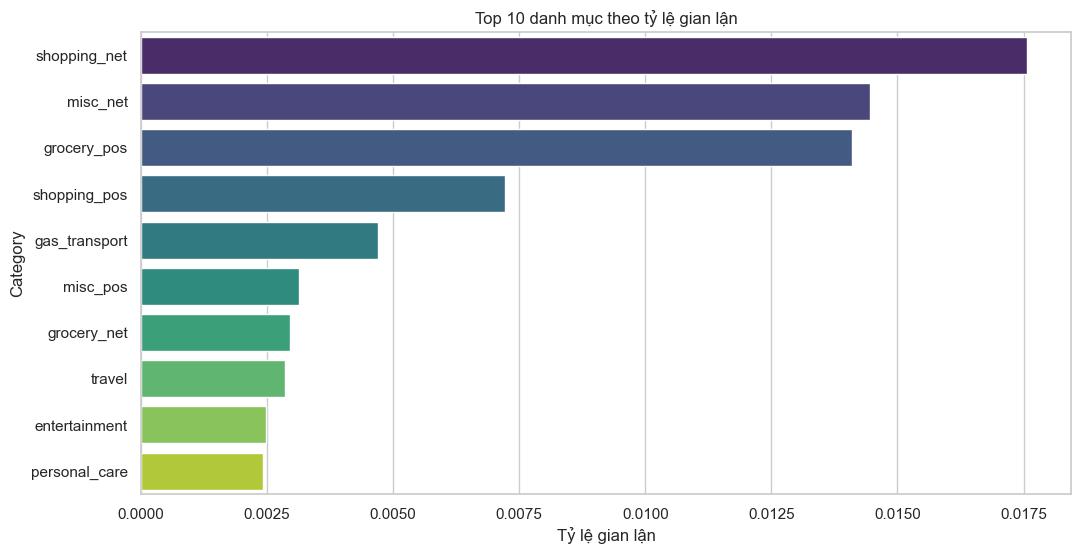

In [18]:

top_categories = (
    eda_train.groupby("category")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=top_categories, y="category", x=TARGET, palette="viridis")
plt.title("Top 10 danh mục theo tỷ lệ gian lận")
plt.xlabel("Tỷ lệ gian lận")
plt.ylabel("Category")
plt.show()


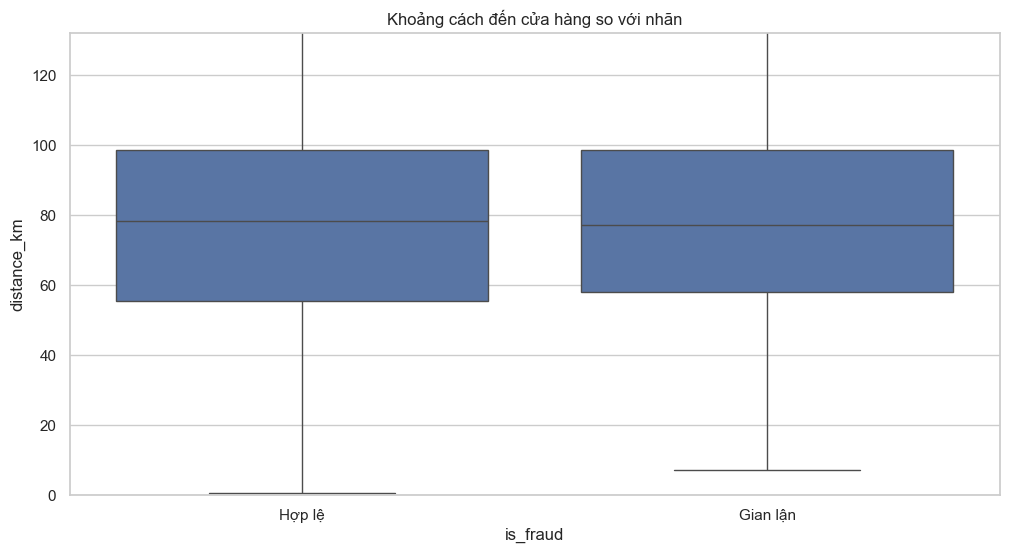

In [19]:

sample_size = min(len(eda_train), 50000)
sns.boxplot(
    data=eda_train.sample(sample_size, random_state=RANDOM_STATE),
    x=TARGET,
    y="distance_km",
)
plt.title("Khoảng cách đến cửa hàng so với nhãn")
plt.xticks([0, 1], ["Hợp lệ", "Gian lận"])
plt.ylim(0, np.nanpercentile(eda_train["distance_km"], 99))
plt.show()


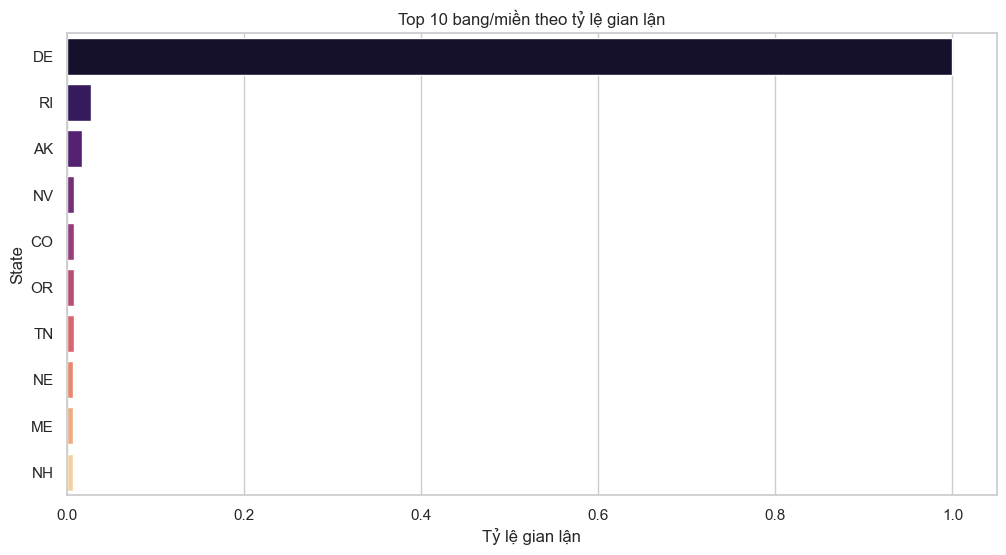

In [20]:

top_states = (
    eda_train.groupby("state")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=top_states, y="state", x=TARGET, palette="magma")
plt.title("Top 10 bang/miền theo tỷ lệ gian lận")
plt.xlabel("Tỷ lệ gian lận")
plt.ylabel("State")
plt.show()


### Các Feature Nâng Cao

Sinh các feature thống kê theo merchant/cardholder theo cách an toàn khi chạy lại notebook.


In [21]:
ADVANCED_FEATURE_COLUMNS = [
    'trans_count_hourly',
    'trans_count_daily',
    'merchant_fraud_rate',
    'merchant_trans_count',
    'merchant_avg_amount',
    'amt_x_distance',
    'age_group',
    'time_since_last_transaction_min',
]


def build_train_stats(df: pd.DataFrame) -> dict:
    """Tính statistics chỉ từ train split để tái sử dụng cho validation/test."""
    merchant_stats = (
        df.groupby('merchant')
        .agg(
            merchant_fraud_rate=(TARGET, 'mean'),
            merchant_trans_count=(TARGET, 'size'),
            merchant_avg_amount=('amt', 'mean'),
        )
        .reset_index()
    )
    return {
        'merchant_stats': merchant_stats,
    }


def add_advanced_features(df: pd.DataFrame, train_stats: dict | None = None) -> pd.DataFrame:
    """Thêm advanced features theo cách rerun-safe và tránh sinh cột _x/_y."""
    df = df.copy()
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')

    existing_generated = [col for col in ADVANCED_FEATURE_COLUMNS if col in df.columns]
    if existing_generated:
        df = df.drop(columns=existing_generated, errors='ignore')

    suffix_cols = [col for col in df.columns if col.endswith(('_x', '_y'))]
    if suffix_cols:
        raise ValueError(f"Phát hiện cột suffix bất thường trước khi tạo features: {suffix_cols}")

    df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)

    df['trans_hour_bucket'] = df['trans_date_trans_time'].dt.floor('h')
    df['trans_day_bucket'] = df['trans_date_trans_time'].dt.floor('D')
    df['trans_count_hourly'] = df.groupby(['cc_num', 'trans_hour_bucket']).cumcount() + 1
    df['trans_count_daily'] = df.groupby(['cc_num', 'trans_day_bucket']).cumcount() + 1

    if train_stats is None:
        train_stats = build_train_stats(df)

    merchant_stats = train_stats.get('merchant_stats')
    if merchant_stats is not None:
        df = df.merge(merchant_stats, on='merchant', how='left', validate='m:1')

    df['amt_x_distance'] = df['amt'] * df['distance_km']

    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 18, 25, 35, 45, 55, 65, 200],
        labels=['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+'],
        include_lowest=True,
    )

    df['time_since_last_transaction_min'] = (
        df.groupby('cc_num')['trans_date_trans_time']
        .diff()
        .dt.total_seconds()
        .div(60)
        .fillna(0)
    )

    df = df.drop(columns=['trans_hour_bucket', 'trans_day_bucket'], errors='ignore')

    suffix_cols = [col for col in df.columns if col.endswith(('_x', '_y'))]
    if suffix_cols:
        raise ValueError(f"Phát hiện cột suffix bất thường sau khi tạo features: {suffix_cols}")

    return df


print("Đã định nghĩa build_train_stats() và add_advanced_features() theo hướng rerun-safe.")
print("Đã bỏ các cardholder history features để tránh cold-start missing trên holdout test.")



Đã định nghĩa build_train_stats() và add_advanced_features() theo hướng rerun-safe.
Đã bỏ các cardholder history features để tránh cold-start missing trên holdout test.


In [22]:
# ===== RECREATE EDA DATA FROM CHRONOLOGICAL SPLITS =====
print("=" * 70)
print("Tạo EDA features từ train_split, validation_split, test_df holdout")
print("=" * 70)

eda_train = add_eda_features(train_split)
eda_validation = add_eda_features(validation_split)
eda_test = add_eda_features(test_df)

print("\nHình dạng sau add_eda_features:")
print(f"  - eda_train: {eda_train.shape}")
print(f"  - eda_validation: {eda_validation.shape}")
print(f"  - eda_test: {eda_test.shape}")

train_stats = build_train_stats(eda_train)

eda_train = add_advanced_features(eda_train, train_stats=train_stats)
eda_validation = add_advanced_features(eda_validation, train_stats=train_stats)
eda_test = add_advanced_features(eda_test, train_stats=train_stats)

print("\nHình dạng sau add_advanced_features:")
print(f"  - eda_train: {eda_train.shape}")
print(f"  - eda_validation: {eda_validation.shape}")
print(f"  - eda_test: {eda_test.shape}")

print("\n✓ Advanced features được fit từ train_split và áp dụng nhất quán cho validation/test")
print("✓ Không còn merge sinh cột _x/_y khi rerun cell")


Tạo EDA features từ train_split, validation_split, test_df holdout

Hình dạng sau add_eda_features:
  - eda_train: (1037340, 30)
  - eda_validation: (259335, 30)
  - eda_test: (555719, 30)

Hình dạng sau add_advanced_features:
  - eda_train: (1037340, 38)
  - eda_validation: (259335, 38)
  - eda_test: (555719, 38)

✓ Advanced features được fit từ train_split và áp dụng nhất quán cho validation/test
✓ Không còn merge sinh cột _x/_y khi rerun cell


Top 15 features có tương quan mạnh nhất với target (is_fraud):
is_fraud                           1.000000
amt                                0.218748
amt_x_distance                     0.206782
amt_log                            0.119925
merchant_fraud_rate                0.074584
trans_count_hourly                 0.071186
merchant_avg_amount                0.053300
time_since_last_transaction_min   -0.018032
trans_count_daily                  0.015655
month                             -0.014409
hour                               0.012588
age                                0.010846
unix_time                         -0.009303
Unnamed: 0                        -0.008630
merchant_trans_count               0.007411
Name: is_fraud, dtype: float64



Top 15 features có tương quan mạnh nhất với target (is_fraud):
is_fraud                           1.000000
amt                                0.218748
amt_x_distance                     0.206782
amt_log                            0.119925
merchant_fraud_rate                0.074584
trans_count_hourly                 0.071186
merchant_avg_amount                0.053300
time_since_last_transaction_min   -0.018032
trans_count_daily                  0.015655
month                             -0.014409
hour                               0.012588
age                                0.010846
unix_time                         -0.009303
Unnamed: 0                        -0.008630
merchant_trans_count               0.007411
Name: is_fraud, dtype: float64



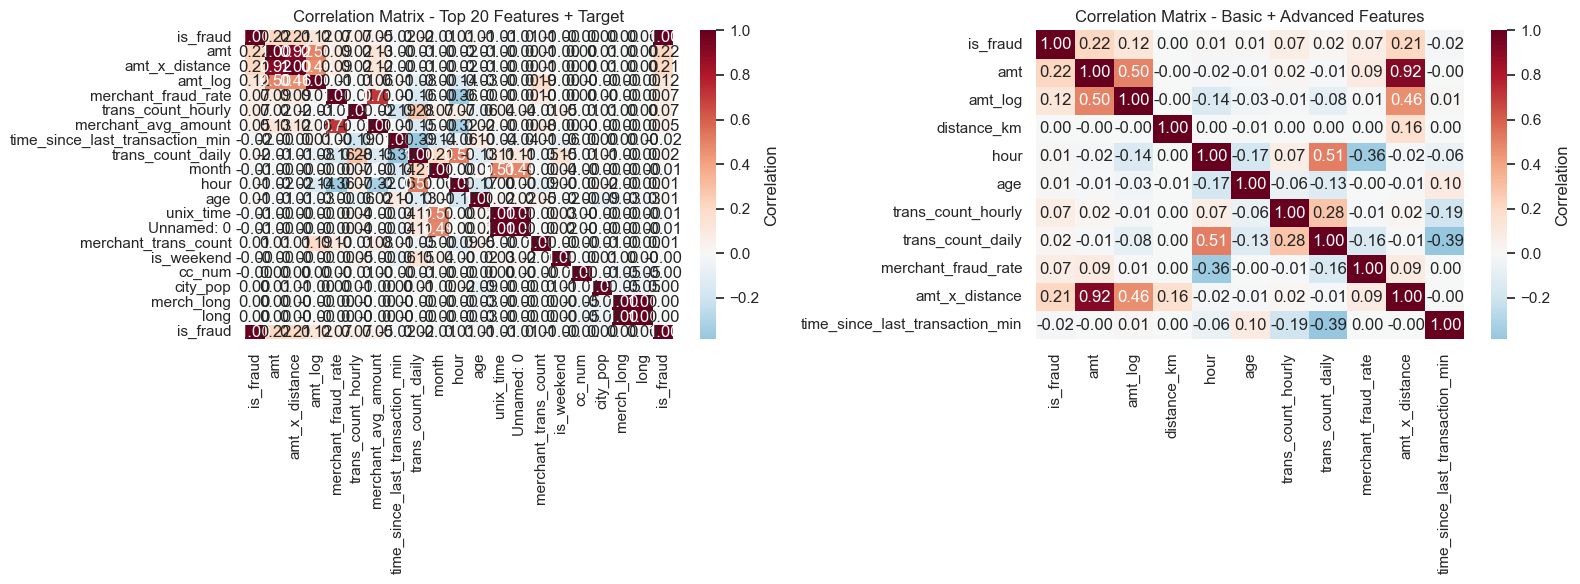

In [23]:
# Chọn các features số để tính correlation
numeric_features_all = eda_train.select_dtypes(include=[np.number]).columns.tolist()

# Tính correlation với target
correlation_with_target = eda_train[numeric_features_all].corr()[TARGET].sort_values(key=abs, ascending=False)
print("Top 15 features có tương quan mạnh nhất với target (is_fraud):")
print(correlation_with_target.head(15))
print()

# Vẽ heatmap correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Top 20 features
top_features = correlation_with_target.head(20).index.tolist() + [TARGET]
corr_subset = eda_train[top_features].corr()
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="RdBu_r", center=0, 
            ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title("Correlation Matrix - Top 20 Features + Target")

# Heatmap 2: Correlation từ basic features + advanced features
important_features = ['is_fraud', 'amt', 'amt_log', 'distance_km', 'hour', 'age', 
                      'trans_count_hourly', 'trans_count_daily', 'merchant_fraud_rate',
                      'amt_x_distance', 'distance_ratio', 'amount_ratio', 'time_since_last_transaction_min']
important_features = [f for f in important_features if f in eda_train.columns]
corr_important = eda_train[important_features].corr()
sns.heatmap(corr_important, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title("Correlation Matrix - Basic + Advanced Features")

plt.tight_layout()
plt.show()

In [24]:
# Phân loại features theo kiểu dữ liệu
feature_summary = pd.DataFrame({
    'Loại dữ liệu': ['Numeric', 'Categorical', 'DateTime', 'Boolean', 'Object'],
    'Số lượng': [
        len(eda_train.select_dtypes(include=[np.number]).columns),
        len(eda_train.select_dtypes(include=['category']).columns),
        len(eda_train.select_dtypes(include=['datetime64']).columns),
        len(eda_train.select_dtypes(include=['bool']).columns),
        len(eda_train.select_dtypes(include=['object']).columns),
    ]
})

total_features = eda_train.shape[1] - 1  # Trừ target
print(f"Tổng số features: {total_features}")
print(f"Bao gồm target '{TARGET}': {eda_train.shape[1]}")
print("\nPhân loại features theo kiểu dữ liệu:")
display(feature_summary[feature_summary['Số lượng'] > 0])

print("\nFeatures mới từ Advanced Engineering:")
original_features = {'trans_date_trans_time', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 
                     'amt', 'hour', 'dayofweek', 'month', 'is_weekend', 'age', 'distance_km', 'amt_log'}
new_features_added = [col for col in eda_train.columns if col not in original_features 
                       and col not in train_df.columns and col != TARGET]
print(f"Số lượng features mới: {len(new_features_added)}")
display(pd.DataFrame({'Feature': sorted(new_features_added)}))

Tổng số features: 37
Bao gồm target 'is_fraud': 38

Phân loại features theo kiểu dữ liệu:


Tổng số features: 37
Bao gồm target 'is_fraud': 38

Phân loại features theo kiểu dữ liệu:


,Loại dữ liệu,Số lượng
0,Numeric,25
1,Categorical,1
2,DateTime,2
4,Object,10


Tổng số features: 37
Bao gồm target 'is_fraud': 38

Phân loại features theo kiểu dữ liệu:


,Loại dữ liệu,Số lượng
0,Numeric,25
1,Categorical,1
2,DateTime,2
4,Object,10



Features mới từ Advanced Engineering:
Số lượng features mới: 8


,Feature
0,age_group
1,amt_x_distance
2,merchant_avg_amount
3,merchant_fraud_rate
4,merchant_trans_count
5,time_since_last_transaction_min
6,trans_count_daily
7,trans_count_hourly


## 2.6 Lựa Chọn Đặc Trưng

Xếp hạng feature bằng correlation, mutual information và tree importance, sau đó hợp nhất điểm để lấy top-k.


In [25]:
# 2.6.1 Ranking Features bằng Correlation
from sklearn.feature_selection import mutual_info_classif

feature_selection_exclude = {'Unnamed: 0', 'cc_num', 'zip', 'unix_time'}
numeric_features_for_fs = [
    col for col in eda_train.columns
    if col != TARGET
    and col not in feature_selection_exclude
    and pd.api.types.is_numeric_dtype(eda_train[col])
]

# Correlation-based ranking
corr_ranking = eda_train[numeric_features_for_fs].corrwith(eda_train[TARGET]).abs().sort_values(ascending=False)
print("=" * 70)
print("2.6.1 CORRELATION-BASED FEATURE RANKING")
print("=" * 70)
print(f"Loại khỏi feature ranking các cột định danh/nhiễu: {sorted(feature_selection_exclude)}")
print(corr_ranking.head(20))
print()

# Normalize correlation ranking (0-1)
corr_rank_norm = (corr_ranking - corr_ranking.min()) / (corr_ranking.max() - corr_ranking.min())


2.6.1 CORRELATION-BASED FEATURE RANKING
Loại khỏi feature ranking các cột định danh/nhiễu: ['Unnamed: 0', 'cc_num', 'unix_time', 'zip']
amt                                0.218748
amt_x_distance                     0.206782
amt_log                            0.119925
merchant_fraud_rate                0.074584
trans_count_hourly                 0.071186
merchant_avg_amount                0.053300
time_since_last_transaction_min    0.018032
trans_count_daily                  0.015655
month                              0.014409
hour                               0.012588
age                                0.010846
merchant_trans_count               0.007411
is_weekend                         0.003202
city_pop                           0.001971
merch_long                         0.001947
long                               0.001918
lat                                0.001539
merch_lat                          0.001389
dayofweek                          0.001267
distance_km                 

In [26]:
# 2.6.2 Ranking Features bằng Mutual Information
print("=" * 70)
print("2.6.2 MUTUAL INFORMATION-BASED FEATURE RANKING")
print("=" * 70)

X_mi = eda_train[numeric_features_for_fs].fillna(eda_train[numeric_features_for_fs].mean())
y_mi = eda_train[TARGET]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=numeric_features_for_fs).sort_values(ascending=False)
mi_ranking_df = mi_ranking.rename_axis('feature').reset_index(name='mutual_information')

display(mi_ranking_df.head(20))
print("\nTop 20 mutual-information features:")
print(mi_ranking.head(20))
print()

# Normalize MI ranking (0-1)
mi_rank_norm = (mi_ranking - mi_ranking.min()) / (mi_ranking.max() - mi_ranking.min())


2.6.2 MUTUAL INFORMATION-BASED FEATURE RANKING


2.6.2 MUTUAL INFORMATION-BASED FEATURE RANKING


,feature,mutual_information
0,trans_count_hourly,0.169046
1,is_weekend,0.081474
2,dayofweek,0.039580
3,trans_count_daily,0.027217
4,month,0.021038
5,age,0.017664
6,amt,0.017335
7,amt_log,0.017331
8,hour,0.016238
9,amt_x_distance,0.011670



Top 20 mutual-information features:
trans_count_hourly                 0.169046
is_weekend                         0.081474
dayofweek                          0.039580
trans_count_daily                  0.027217
month                              0.021038
age                                0.017664
amt                                0.017335
amt_log                            0.017331
hour                               0.016238
amt_x_distance                     0.011670
lat                                0.006315
long                               0.006292
city_pop                           0.005320
merchant_fraud_rate                0.002556
merchant_trans_count               0.002548
merchant_avg_amount                0.002489
time_since_last_transaction_min    0.001831
merch_lat                          0.000182
merch_long                         0.000060
distance_km                        0.000000
dtype: float64



In [27]:
# 2.6.3 Ranking Features bằng Tree-based Importance
print("=" * 70)
print("2.6.3 TREE-BASED FEATURE IMPORTANCE RANKING")
print("=" * 70)

# Train một Random Forest nhanh để lấy feature importance
X_rf = X_mi.copy()
rf_quick = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1, max_depth=10)
rf_quick.fit(X_rf, y_mi)

importance_ranking = pd.Series(rf_quick.feature_importances_, 
                               index=numeric_features_for_fs).sort_values(ascending=False)
print(importance_ranking.head(20))
print()

# Normalize importance ranking (0-1)
import_rank_norm = (importance_ranking - importance_ranking.min()) / (importance_ranking.max() - importance_ranking.min())


2.6.3 TREE-BASED FEATURE IMPORTANCE RANKING
amt                                0.212691
amt_log                            0.197773
hour                               0.144399
merchant_avg_amount                0.096762
merchant_trans_count               0.090181
amt_x_distance                     0.070831
merchant_fraud_rate                0.053507
age                                0.038460
time_since_last_transaction_min    0.027959
trans_count_daily                  0.014571
trans_count_hourly                 0.010453
city_pop                           0.009256
distance_km                        0.008598
month                              0.005011
lat                                0.004702
merch_lat                          0.004359
merch_long                         0.004188
long                               0.003867
dayofweek                          0.001962
is_weekend                         0.000469
dtype: float64



In [28]:
# 2.6.4 Consolidate Rankings và Chọn Top Features
print("=" * 70)
print("2.6.4 CONSOLIDATED FEATURE RANKING (Average of 3 Methods)")
print("=" * 70)

ranking_df = (
    pd.concat(
        [
            corr_rank_norm.rename('correlation'),
            mi_rank_norm.rename('mutual_info'),
            import_rank_norm.rename('tree_importance'),
        ],
        axis=1,
    )
    .fillna(0)
    .reset_index()
    .rename(columns={'index': 'feature'})
)

ranking_df['avg_score'] = ranking_df[['correlation', 'mutual_info', 'tree_importance']].mean(axis=1)
ranking_df = ranking_df.sort_values('avg_score', ascending=False).reset_index(drop=True)
ranking_df['rank'] = range(1, len(ranking_df) + 1)

TOP_K = 20
print(f"\nTop {TOP_K} Features (theo điểm trung bình của 3 tiêu chí):\n")
display(ranking_df.head(TOP_K)[['rank', 'feature', 'correlation', 'mutual_info', 'tree_importance', 'avg_score']])

selected_features = ranking_df.head(TOP_K)['feature'].tolist()
print(f"\n✓ Đã chọn TOP-{TOP_K} features có khả năng dự đoán cao nhất:")
print(selected_features)

important_features = selected_features
print(f"\nSố lượng features được chọn: {len(important_features)}")

2.6.4 CONSOLIDATED FEATURE RANKING (Average of 3 Methods)

Top 20 Features (theo điểm trung bình của 3 tiêu chí):



,rank,feature,correlation,mutual_info,tree_importance,avg_score
0,1,amt,1.000000,0.102544,1.000000,0.700848
1,2,amt_log,0.547601,0.102521,0.929710,0.526611
2,3,trans_count_hourly,0.324482,1.000000,0.047045,0.457176
3,4,amt_x_distance,0.945225,0.069037,0.331552,0.448605
4,5,hour,0.056223,0.096055,0.678209,0.276829
5,6,merchant_avg_amount,0.242600,0.014721,0.453740,0.237020
6,7,merchant_fraud_rate,0.340036,0.015120,0.249918,0.201691
7,8,is_weekend,0.013254,0.481960,0.000000,0.165071
8,9,merchant_trans_count,0.032526,0.015071,0.422728,0.156775
9,10,age,0.048251,0.104495,0.179018,0.110588



✓ Đã chọn TOP-20 features có khả năng dự đoán cao nhất:
['amt', 'amt_log', 'trans_count_hourly', 'amt_x_distance', 'hour', 'merchant_avg_amount', 'merchant_fraud_rate', 'is_weekend', 'merchant_trans_count', 'age', 'trans_count_daily', 'dayofweek', 'time_since_last_transaction_min', 'month', 'city_pop', 'lat', 'long', 'distance_km', 'merch_long', 'merch_lat']

Số lượng features được chọn: 20


## 2.7 Chuẩn Bị Dữ Liệu Cho Modeling

Loại cột định danh, đồng bộ schema train/validation/test và giữ lại feature set cuối cho mô hình.


In [29]:
# 2.7.4 Quy định danh sách cột loại bỏ cho modeling
identifier_like_cols = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'zip',
    'trans_num', 'unix_time', 'trans_date_trans_time', 'dob',
    'city', 'merchant'
]

def missing_table(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    tbl = (
        df.isna().sum()
        .rename('số_giá_trị_thiếu')
        .to_frame()
        .assign(tỷ_lệ_phần_trăm=lambda x: x['số_giá_trị_thiếu'] / total_rows * 100)
        .sort_values(['số_giá_trị_thiếu', 'tỷ_lệ_phần_trăm'], ascending=False)
    )
    return tbl.query('số_giá_trị_thiếu > 0')

drop_reason_df = pd.DataFrame({
    'cột': identifier_like_cols,
    'lý_do_loại_bỏ': [
        'chỉ số dòng, không có ý nghĩa dự đoán',
        'định danh thẻ, nguy cơ overfitting cao',
        'tên riêng, cardinality cao',
        'tên riêng, cardinality cao',
        'địa chỉ cụ thể, cardinality cao',
        'mã zip, tính định danh cao',
        'mã giao dịch, định danh duy nhất',
        'thời gian dạng số, được thay bằng feature đã tạo',
        'đã tách thành hour/day/month',
        'đã dùng để tạo age',
        'địa danh cụ thể, giảm tổng quát hóa',
        'tên merchant cụ thể, cardinality cao'
    ]
})
display(drop_reason_df)



,cột,lý_do_loại_bỏ
0,Unnamed: 0,"chỉ số dòng, không có ý nghĩa dự đoán"
1,cc_num,"định danh thẻ, nguy cơ overfitting cao"
2,first,"tên riêng, cardinality cao"
3,last,"tên riêng, cardinality cao"
4,street,"địa chỉ cụ thể, cardinality cao"
5,zip,"mã zip, tính định danh cao"
6,trans_num,"mã giao dịch, định danh duy nhất"
7,unix_time,"thời gian dạng số, được thay bằng feature đã tạo"
8,trans_date_trans_time,đã tách thành hour/day/month
9,dob,đã dùng để tạo age


In [30]:
# 2.7.5 Sử dụng dữ liệu đã có advanced features cho modeling
def add_model_features(df: pd.DataFrame) -> pd.DataFrame:
    """Loại bỏ cột định danh và chặn schema lỗi trước khi modeling."""
    suffix_cols = [col for col in df.columns if col.endswith(('_x', '_y'))]
    if suffix_cols:
        raise ValueError(f"Schema không hợp lệ cho modeling vì còn cột suffix: {suffix_cols}")
    return df.drop(columns=identifier_like_cols, errors='ignore').copy()

train_fe = add_model_features(eda_train)
validation_fe = add_model_features(eda_validation)
test_fe = add_model_features(eda_test)

print('Hình dạng sau feature engineering - train:', train_fe.shape)
print('Hình dạng sau feature engineering - validation:', validation_fe.shape)
print('Hình dạng sau feature engineering - test: ', test_fe.shape)
display(train_fe.head(3))


Hình dạng sau feature engineering - train: (1037340, 26)
Hình dạng sau feature engineering - validation: (259335, 26)
Hình dạng sau feature engineering - test:  (555719, 26)


,category,amt,gender,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,dayofweek,month,is_weekend,age,distance_km,amt_log,trans_count_hourly,trans_count_daily,merchant_fraud_rate,merchant_trans_count,merchant_avg_amount,amt_x_distance,age_group,time_since_last_transaction_min
0,misc_net,7.27,F,WY,43.0048,-108.8964,1645,Information systems manager,43.974711,-109.741904,0,12,1,1,0,32.870637,127.606239,2.112635,1,1,0.010902,1009,81.451100,927.697358,26-35,0.00
1,gas_transport,52.94,F,WY,43.0048,-108.8964,1645,Information systems manager,42.018766,-109.044172,0,8,2,1,0,32.873374,110.308921,3.987872,1,1,0.002808,2137,64.002845,5839.754292,26-35,1197.70
2,gas_transport,82.08,F,WY,43.0048,-108.8964,1645,Information systems manager,42.961335,-109.157564,0,8,2,1,0,32.873374,21.787261,4.419804,2,2,0.003352,2088,63.274646,1788.298403,26-35,2.65


In [31]:

# 2.7.6 Kiểm tra lại dữ liệu sau feature engineering
train_missing_fe = missing_table(train_fe)
test_missing_fe = missing_table(test_fe)
single_value_fe = [col for col in train_fe.columns if train_fe[col].nunique(dropna=False) <= 1 and col != TARGET]

print('Giá trị thiếu sau feature engineering - train:')
display(train_missing_fe if not train_missing_fe.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Giá trị thiếu sau feature engineering - test:')
display(test_missing_fe if not test_missing_fe.empty else pd.DataFrame({'thông_báo': ['Không có giá trị thiếu']}))

print('Cột hằng sau feature engineering:')
display(pd.DataFrame({'cột': single_value_fe}) if single_value_fe else pd.DataFrame({'thông_báo': ['Không có cột hằng']}))

if single_value_fe:
    train_fe = train_fe.drop(columns=single_value_fe, errors='ignore')
    test_fe = test_fe.drop(columns=single_value_fe, errors='ignore')
    print('Đã loại bỏ các cột hằng sau feature engineering.')

Giá trị thiếu sau feature engineering - train:


,thông_báo
0,Không có giá trị thiếu


Giá trị thiếu sau feature engineering - test:


,thông_báo
0,Không có giá trị thiếu


Cột hằng sau feature engineering:


,thông_báo
0,Không có cột hằng


In [32]:
# 2.7.7 Tách X/y từ pre-split data và áp dụng feature selection
print("=" * 70)
print("2.7.7 Tách X/y từ pre-split data + áp dụng selected_features")
print("=" * 70)

selected_features_available = [
    col for col in selected_features
    if col in train_fe.columns and col in validation_fe.columns and col in test_fe.columns
]

if not selected_features_available:
    raise ValueError("Không có selected_features nào tồn tại đồng thời trên train/validation/test.")

missing_sensitive_features = [
    col for col in selected_features_available
    if train_fe[col].isna().any() or validation_fe[col].isna().any() or test_fe[col].isna().any()
]

selected_features_model = [
    col for col in selected_features_available
    if col not in missing_sensitive_features
]

if not selected_features_model:
    raise ValueError("Tất cả selected_features đều bị loại vì missing trên train/validation/test.")

dropped_unavailable_features = [
    col for col in selected_features
    if col not in selected_features_available
]

X_train_base = train_fe[selected_features_model].copy()
y_train_base = train_fe[TARGET].copy()

X_valid = validation_fe[selected_features_model].copy()
y_valid = validation_fe[TARGET].copy()

X_test = test_fe[selected_features_model].copy()
y_test = test_fe[TARGET].copy()

# Dữ liệu modeling mặc định bắt đầu từ base set, các bước sau có thể tạo biến riêng từ đây
X_train_model = X_train_base.copy()
y_train_model = y_train_base.copy()

categorical_features = X_train_base.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = [col for col in X_train_base.columns if col not in categorical_features]

feature_group_df = pd.DataFrame({
    'nhóm': ['numeric', 'categorical'],
    'số_lượng': [len(numeric_features), len(categorical_features)],
    'ví_dụ': [', '.join(numeric_features[:8]), ', '.join(categorical_features[:8])],
})
display(feature_group_df)

print('\n✓ Số lượng features được áp dụng cho modeling:', len(selected_features_model))
print(selected_features_model)

if dropped_unavailable_features:
    print('\nCác feature được rank cao nhưng bị loại khỏi modeling vì không còn sau bước drop cột định danh:')
    print(dropped_unavailable_features)

if missing_sensitive_features:
    print('\nCác feature được rank cao nhưng bị loại khỏi modeling vì còn missing trên train/validation/test:')
    print(missing_sensitive_features)

print('\n✓ Hình dạng tập chia (base set trước resampling):')
print(f'  Train base: X={X_train_base.shape}, y={y_train_base.shape}')
print(f'  Validation: X={X_valid.shape}, y={y_valid.shape}')
print(f'  Test holdout: X={X_test.shape}, y={y_test.shape}')


2.7.7 Tách X/y từ pre-split data + áp dụng selected_features


2.7.7 Tách X/y từ pre-split data + áp dụng selected_features


,nhóm,số_lượng,ví_dụ
0,numeric,20,"amt, amt_log, trans_count_hourly, amt_x_distan..."
1,categorical,0,



✓ Số lượng features được áp dụng cho modeling: 20
['amt', 'amt_log', 'trans_count_hourly', 'amt_x_distance', 'hour', 'merchant_avg_amount', 'merchant_fraud_rate', 'is_weekend', 'merchant_trans_count', 'age', 'trans_count_daily', 'dayofweek', 'time_since_last_transaction_min', 'month', 'city_pop', 'lat', 'long', 'distance_km', 'merch_long', 'merch_lat']

✓ Hình dạng tập chia (base set trước resampling):
  Train base: X=(1037340, 20), y=(1037340,)
  Validation: X=(259335, 20), y=(259335,)
  Test holdout: X=(555719, 20), y=(555719,)


In [33]:
# Sanity checks cho modeling inputs
print("\nSANITY CHECKS")
print("=" * 70)

assert len(train_fe) == len(train_split), "train_fe không khớp số dòng với train_split"
assert len(validation_fe) == len(validation_split), "validation_fe không khớp số dòng với validation_split"
assert len(test_fe) == len(test_df), "test_fe không khớp số dòng với test_df"
assert list(X_train_base.columns) == list(X_valid.columns) == list(X_test.columns), "Schema giữa train/valid/test không đồng nhất"
assert not any(col.endswith(('_x', '_y')) for col in train_fe.columns), "train_fe còn cột suffix _x/_y"
assert not any(col.endswith(('_x', '_y')) for col in validation_fe.columns), "validation_fe còn cột suffix _x/_y"
assert not any(col.endswith(('_x', '_y')) for col in test_fe.columns), "test_fe còn cột suffix _x/_y"

print("✓ train/validation/test giữ đúng số dòng sau feature engineering")
print("✓ Schema X_train_base/X_valid/X_test đồng nhất")
print("✓ Không còn cột _x/_y trong feature sets")
print(f"✓ Overlap cardholder train-valid: {len(set(train_split['cc_num']) & set(validation_split['cc_num'])):,}")



SANITY CHECKS
✓ train/validation/test giữ đúng số dòng sau feature engineering
✓ Schema X_train_base/X_valid/X_test đồng nhất
✓ Không còn cột _x/_y trong feature sets
✓ Overlap cardholder train-valid: 908


In [34]:
# Tóm tắt dữ liệu sẵn sàng cho modeling
model_ready_summary = pd.DataFrame({
    'tập_dữ_liệu': ['train_base', 'validation', 'test'],
    'số_dòng': [len(X_train_base), len(X_valid), len(X_test)],
    'số_features': [X_train_base.shape[1], X_valid.shape[1], X_test.shape[1]],
    'fraud_rate': [y_train_base.mean(), y_valid.mean(), y_test.mean()],
})

display(model_ready_summary)


,tập_dữ_liệu,số_dòng,số_features,fraud_rate
0,train_base,1037340,20,0.005753
1,validation,259335,20,0.005931
2,test,555719,20,0.003860


## 2.8 Xử Lý Imbalance

Phân tích mất cân bằng lớp và chỉ resample trên train base trước khi huấn luyện.


2.8.1 CLASS IMBALANCE ANALYSIS

✓ Imbalance Ratio in Train Base & Validation:


2.8.1 CLASS IMBALANCE ANALYSIS

✓ Imbalance Ratio in Train Base & Validation:


,Class,Count_Train_Base,Pct_Train_Base,Count_Valid,Pct_Valid
0,Legitimate (0),1031372,99.424682,257797,99.406945
1,Fraud (1),5968,0.575318,1538,0.593055


2.8.1 CLASS IMBALANCE ANALYSIS

✓ Imbalance Ratio in Train Base & Validation:


,Class,Count_Train_Base,Pct_Train_Base,Count_Valid,Pct_Valid
0,Legitimate (0),1031372,99.424682,257797,99.406945
1,Fraud (1),5968,0.575318,1538,0.593055



⚠️ IMBALANCE RATIO (train base): 1:172.8
   → Resampling sẽ chỉ áp dụng trên train base, validation/test giữ nguyên


2.8.1 CLASS IMBALANCE ANALYSIS

✓ Imbalance Ratio in Train Base & Validation:


,Class,Count_Train_Base,Pct_Train_Base,Count_Valid,Pct_Valid
0,Legitimate (0),1031372,99.424682,257797,99.406945
1,Fraud (1),5968,0.575318,1538,0.593055



⚠️ IMBALANCE RATIO (train base): 1:172.8
   → Resampling sẽ chỉ áp dụng trên train base, validation/test giữ nguyên


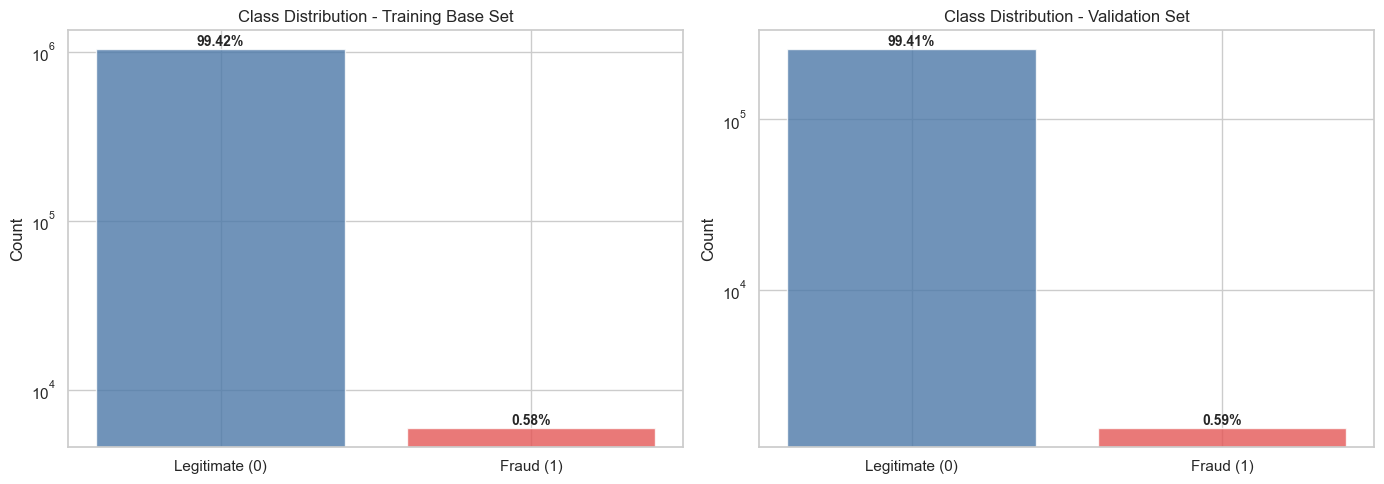


✓ Dữ liệu base đã sẵn sàng cho bước resampling/model training


In [35]:
# 2.8.1 Phân tích Class Imbalance
print("=" * 70)
print("2.8.1 CLASS IMBALANCE ANALYSIS")
print("=" * 70)

imbalance_stats = pd.DataFrame({
    'Class': ['Legitimate (0)', 'Fraud (1)'],
    'Count_Train_Base': [(y_train_base == 0).sum(), (y_train_base == 1).sum()],
    'Count_Valid': [(y_valid == 0).sum(), (y_valid == 1).sum()],
})

imbalance_stats['Pct_Train_Base'] = imbalance_stats['Count_Train_Base'] / imbalance_stats['Count_Train_Base'].sum() * 100
imbalance_stats['Pct_Valid'] = imbalance_stats['Count_Valid'] / imbalance_stats['Count_Valid'].sum() * 100
imbalance_stats['Ratio_Train_Base'] = imbalance_stats.loc[0, 'Count_Train_Base'] / (imbalance_stats.loc[1, 'Count_Train_Base'] + 1e-6)

print("\n✓ Imbalance Ratio in Train Base & Validation:")
display(imbalance_stats[['Class', 'Count_Train_Base', 'Pct_Train_Base', 'Count_Valid', 'Pct_Valid']])

print(f"\n⚠️ IMBALANCE RATIO (train base): 1:{imbalance_stats.loc[0, 'Count_Train_Base'] / (imbalance_stats.loc[1, 'Count_Train_Base'] + 1e-6):.1f}")
print("   → Resampling sẽ chỉ áp dụng trên train base, validation/test giữ nguyên")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (ax, col) in enumerate(zip(axes, ['Count_Train_Base', 'Count_Valid'])):
    pct_col = 'Pct_Train_Base' if col == 'Count_Train_Base' else 'Pct_Valid'
    colors = ['#4C78A8', '#E45756']
    bars = ax.bar(imbalance_stats['Class'], imbalance_stats[col], color=colors, alpha=0.8)
    ax.set_ylabel('Count')
    ax.set_title(f"Class Distribution - {'Training Base' if idx == 0 else 'Validation'} Set")
    ax.set_yscale('log')
    for bar, pct in zip(bars, imbalance_stats[pct_col]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{pct:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Dữ liệu base đã sẵn sàng cho bước resampling/model training")


In [36]:
# 2.8.2 SMOTENC/SMOTE - Xử Lý Imbalance theo loại feature
print("\n" + "=" * 70)
print("2.8.2 APPLYING SMOTENC/SMOTE")
print("=" * 70)

from imblearn.over_sampling import SMOTE, SMOTENC

categorical_cols = X_train_base.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_indices = [X_train_base.columns.get_loc(col) for col in categorical_cols]

print("\n📋 Bước 1: Chuẩn bị feature space cho resampling")
print(f"  Categorical columns: {categorical_cols}")
print(f"  Categorical indices: {categorical_indices}")

print("\n📊 Before resampling (train base):")
print(f"  Legitimate (0): {(y_train_base == 0).sum():,}")
print(f"  Fraud (1):      {(y_train_base == 1).sum():,}")
print(f"  Ratio: 1:{(y_train_base == 0).sum() / (y_train_base == 1).sum():.1f}")

if categorical_cols:
    X_train_resample_input = X_train_base.copy()
    for col in categorical_cols:
        X_train_resample_input[col] = X_train_resample_input[col].astype(str)
    sampler = SMOTENC(
        categorical_features=categorical_indices,
        random_state=RANDOM_STATE,
        k_neighbors=5,
    )
    sampler_name = 'SMOTENC'
else:
    X_train_resample_input = X_train_base.copy()
    sampler = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    sampler_name = 'SMOTE'

X_train_resampled_arr, y_train_resampled = sampler.fit_resample(X_train_resample_input, y_train_base)
X_train_resampled = pd.DataFrame(X_train_resampled_arr, columns=X_train_base.columns)

for col in numeric_features:
    X_train_resampled[col] = pd.to_numeric(X_train_resampled[col], errors='coerce')
for col in categorical_cols:
    X_train_resampled[col] = X_train_resampled[col].astype(str)

X_train_model = X_train_resampled.copy()
y_train_model = pd.Series(y_train_resampled, name=TARGET)

print(f"\n✓ After {sampler_name}:")
print(f"  Legitimate (0): {(y_train_model == 0).sum():,}")
print(f"  Fraud (1):      {(y_train_model == 1).sum():,}")
print(f"  Ratio: 1:{(y_train_model == 0).sum() / (y_train_model == 1).sum():.1f}")

print(f"\n✓ Training data cho modeling sau {sampler_name}: {X_train_model.shape}")
print(f"✓ Validation data (không thay đổi): {X_valid.shape}")
print(f"✓ Test data (không thay đổi): {X_test.shape}")
print("✓ X_train_base/y_train_base vẫn được giữ nguyên để notebook rerun ổn định")



2.8.2 APPLYING SMOTENC/SMOTE

📋 Bước 1: Chuẩn bị feature space cho resampling
  Categorical columns: []
  Categorical indices: []

📊 Before resampling (train base):
  Legitimate (0): 1,031,372
  Fraud (1):      5,968
  Ratio: 1:172.8

✓ After SMOTE:
  Legitimate (0): 1,031,372
  Fraud (1):      1,031,372
  Ratio: 1:1.0

✓ Training data cho modeling sau SMOTE: (2062744, 20)
✓ Validation data (không thay đổi): (259335, 20)
✓ Test data (không thay đổi): (555719, 20)
✓ X_train_base/y_train_base vẫn được giữ nguyên để notebook rerun ổn định



2.8.3 VISUALIZE CLASS DISTRIBUTION - BEFORE vs AFTER SMOTE



2.8.3 VISUALIZE CLASS DISTRIBUTION - BEFORE vs AFTER SMOTE


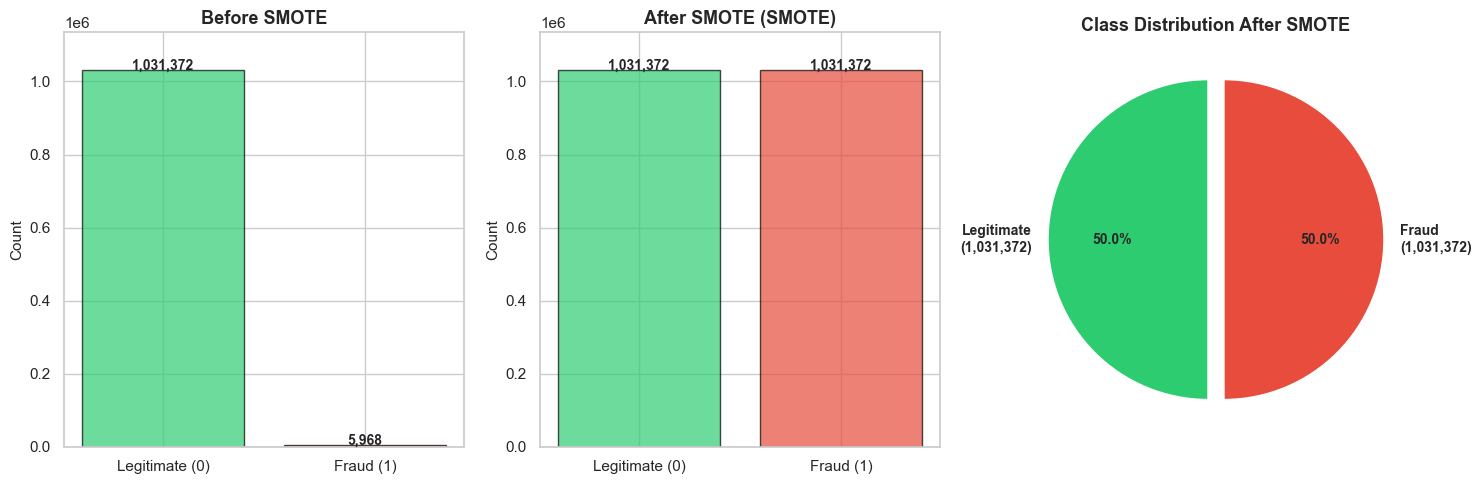


✓ Biểu đồ minh họa sự cân bằng lại class distribution sau khi áp dụng SMOTE


In [37]:
# 2.8.3 Visualize Class Distribution trước/sau SMOTE
print("\n" + "=" * 70)
print("2.8.3 VISUALIZE CLASS DISTRIBUTION - BEFORE vs AFTER SMOTE")
print("=" * 70)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before SMOTE
class_counts_before = y_train_base.value_counts().sort_index()
colors_before = ['#2ecc71', '#e74c3c']  # Green for legitimate, Red for fraud
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts_before.values, color=colors_before, alpha=0.7, edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_ylim(0, max(class_counts_before.values) * 1.1)
for i, v in enumerate(class_counts_before.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# After SMOTE
class_counts_after = y_train_model.value_counts().sort_index()
axes[1].bar(['Legitimate (0)', 'Fraud (1)'], class_counts_after.values, color=colors_before, alpha=0.7, edgecolor='black')
axes[1].set_title(f'After SMOTE ({sampler_name})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_ylim(0, max(class_counts_after.values) * 1.1)
for i, v in enumerate(class_counts_after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart - After SMOTE
sizes_after = class_counts_after.values
labels_after = [f'Legitimate\n({sizes_after[0]:,})', f'Fraud\n({sizes_after[1]:,})']
explode_pie = (0.05, 0.05)
axes[2].pie(sizes_after, labels=labels_after, colors=colors_before, autopct='%1.1f%%', 
            startangle=90, explode=explode_pie, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[2].set_title('Class Distribution After SMOTE', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Biểu đồ minh họa sự cân bằng lại class distribution sau khi áp dụng {sampler_name}")


### Audit Feature Selection

Bảng dưới đây cho thấy feature nào được tạo, được xếp hạng, vào top-k và cuối cùng có được dùng để train model hay không.


In [38]:
all_engineered_features = [col for col in train_fe.columns if col != TARGET]
ranking_feature_set = set(ranking_df['feature'])
selected_feature_set = set(selected_features)
selected_model_feature_set = set(selected_features_model)
missing_feature_set = set(missing_sensitive_features)
dropped_unavailable_feature_set = set(dropped_unavailable_features)

feature_audit_rows = []
for feature in all_engineered_features:
    dtype_name = str(train_fe[feature].dtype)
    if feature in selected_model_feature_set:
        status = 'used_for_modeling'
        reason = 'Top-K và không bị missing trên train/validation/test'
    elif feature in missing_feature_set:
        status = 'removed'
        reason = 'Bị missing trên ít nhất một split'
    elif feature in dropped_unavailable_feature_set:
        status = 'removed'
        reason = 'Không còn sau bước loại cột trước modeling'
    elif feature in selected_feature_set:
        status = 'removed'
        reason = 'Có trong Top-K nhưng bị loại ở bước hậu kiểm'
    elif feature in ranking_feature_set:
        status = 'removed'
        reason = 'Có trong ranking pool nhưng không lọt Top-K'
    else:
        status = 'removed'
        reason = 'Không nằm trong ranking pool (ví dụ: categorical/not ranked)'

    feature_audit_rows.append({
        'feature': feature,
        'dtype': dtype_name,
        'in_ranking_pool': feature in ranking_feature_set,
        'in_top_k_ranked': feature in selected_feature_set,
        'in_final_model': feature in selected_model_feature_set,
        'status': status,
        'reason': reason,
    })

feature_audit_df = pd.DataFrame(feature_audit_rows).sort_values(
    by=['in_final_model', 'in_top_k_ranked', 'in_ranking_pool', 'feature'],
    ascending=[False, False, False, True]
).reset_index(drop=True)

model_feature_columns = [col for col in X_train_base.columns]

audit_summary_df = pd.DataFrame({
    'nhóm': ['engineered_feature_pool', 'ranking_pool', 'top_k_ranked', 'final_model_features'],
    'số_lượng': [
        len(all_engineered_features),
        len(ranking_feature_set),
        len(selected_feature_set),
        len(model_feature_columns),
    ]
})

print('Tóm tắt quá trình chọn feature:')
display(audit_summary_df)

print(f"Tổng số cột dùng cho modeling: {len(model_feature_columns)}")
display(pd.DataFrame({
    'stt': range(1, len(model_feature_columns) + 1),
    'cột_modeling': model_feature_columns
}))

if missing_sensitive_features:
    print('Các feature bị loại vì missing trên train/validation/test:')
    display(pd.DataFrame({'feature_bị_loại': missing_sensitive_features}))

print('Bảng audit đầy đủ cho toàn bộ engineered feature pool:')
display(feature_audit_df)

print(f"\nTrain base shape: {X_train_base.shape}")
print(f"Train model shape (sau resampling nếu đã chạy cell 2.8.2): {X_train_model.shape}")
print('Các cột này đã được lọc để không còn missing trên train/validation/test.')


Tóm tắt quá trình chọn feature:


,nhóm,số_lượng
0,engineered_feature_pool,25
1,ranking_pool,20
2,top_k_ranked,20
3,final_model_features,20


Tổng số cột dùng cho modeling: 20


,stt,cột_modeling
0,1,amt
1,2,amt_log
2,3,trans_count_hourly
3,4,amt_x_distance
4,5,hour
5,6,merchant_avg_amount
6,7,merchant_fraud_rate
7,8,is_weekend
8,9,merchant_trans_count
9,10,age


Tóm tắt quá trình chọn feature:


...

Tổng số cột dùng cho modeling: 20


,stt,cột_modeling
0,1,amt
1,2,amt_log
2,3,trans_count_hourly
3,4,amt_x_distance
4,5,hour
5,6,merchant_avg_amount
6,7,merchant_fraud_rate
7,8,is_weekend
8,9,merchant_trans_count
9,10,age


Bảng audit đầy đủ cho toàn bộ engineered feature pool:


,feature,dtype,in_ranking_pool,in_top_k_ranked,in_final_model,status,reason
0,age,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
1,amt,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
2,amt_log,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
3,amt_x_distance,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
4,city_pop,int64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
5,dayofweek,int32,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
6,distance_km,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
7,hour,int32,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
8,is_weekend,int64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...
9,lat,float64,True,True,True,used_for_modeling,Top-K và không bị missing trên train/validatio...



Train base shape: (1037340, 20)
Train model shape (sau resampling nếu đã chạy cell 2.8.2): (2062744, 20)
Các cột này đã được lọc để không còn missing trên train/validation/test.


# 3. Học Máy

Huấn luyện mô hình, chọn threshold trên validation, đánh giá holdout test và lưu artifact.
